## 1. Load Libraries

In [41]:
# Install if needed
# install.packages(c("tidyverse","lubridate","forecast","Metrics","ggplot2"))

library(tidyverse)
library(lubridate)
library(forecast)
library(Metrics)
library(ggplot2)
library(tseries)


## 2. Load Dataset

In [42]:
data <- read.csv("Retail_Dataset2.csv", stringsAsFactors = FALSE)

str(data)
summary(data)
head(data)

'data.frame':	169211 obs. of  11 variables:
 $ Product_id      : int  786725 786743 786967 786856 899538 786726 899733 899398 786806 899734 ...
 $ Product_Code    : chr  "Product_0033" "Product_1825" "Product_0551" "Product_0556" ...
 $ Warehouse       : chr  "Whse_S" "Whse_S" "Whse_S" "Whse_S" ...
 $ Product_Category: chr  "Category_005" "Category_006" "Category_030" "Category_030" ...
 $ Date            : chr  "01/03/2016" "01/03/2016" "01/03/2016" "01/03/2016" ...
 $ Order_Demand    : int  16000 50000 3000 1000 7 2000 2 300 3000 5000 ...
 $ Open            : int  1 1 1 1 1 1 1 1 1 1 ...
 $ Promo           : int  0 0 0 0 0 0 0 0 0 0 ...
 $ StateHoliday    : chr  "0" "0" "0" "0" ...
 $ SchoolHoliday   : int  0 0 0 0 0 0 0 0 0 0 ...
 $ Petrol_price    : int  91 85 85 93 95 80 85 88 95 92 ...


   Product_id      Product_Code        Warehouse         Product_Category  
 Min.   : 690943   Length:169211      Length:169211      Length:169211     
 1st Qu.: 905428   Class :character   Class :character   Class :character  
 Median : 952643   Mode  :character   Mode  :character   Mode  :character  
 Mean   : 952889                                                           
 3rd Qu.:1001417                                                           
 Max.   :1048574                                                           
     Date            Order_Demand          Open            Promo       
 Length:169211      Min.   :      0   Min.   :0.0000   Min.   :0.0000  
 Class :character   1st Qu.:     20   1st Qu.:1.0000   1st Qu.:0.0000  
 Mode  :character   Median :    300   Median :1.0000   Median :0.0000  
                    Mean   :   5248   Mean   :0.8177   Mean   :0.3954  
                    3rd Qu.:   2000   3rd Qu.:1.0000   3rd Qu.:1.0000  
                    Max.   :2500000 

,Product_id,Product_Code,Warehouse,Product_Category,Date,Order_Demand,Open,Promo,StateHoliday,SchoolHoliday,Petrol_price
,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<int>,<int>
1,786725,Product_0033,Whse_S,Category_005,01/03/2016,16000,1,0,0,0,91
2,786743,Product_1825,Whse_S,Category_006,01/03/2016,50000,1,0,0,0,85
3,786967,Product_0551,Whse_S,Category_030,01/03/2016,3000,1,0,0,0,85
4,786856,Product_0556,Whse_S,Category_030,01/03/2016,1000,1,0,0,0,93
5,899538,Product_1844,Whse_A,Category_018,01/03/2016,7,1,0,0,0,95
6,786726,Product_0470,Whse_S,Category_005,01/03/2016,2000,1,0,0,0,80


## 3. Data Cleaning

In [43]:
# Convert Date
data$Date <- as.Date(data$Date)

# Remove NA
data <- na.omit(data)

# Remove brackets and convert to numeric
data$Order_Demand <- gsub("\\(|\\)", "", data$Order_Demand)
data$Order_Demand <- as.numeric(data$Order_Demand)

# Sort
data <- data %>% arrange(Date)

## 4. Outlier Removal (IQR Method)

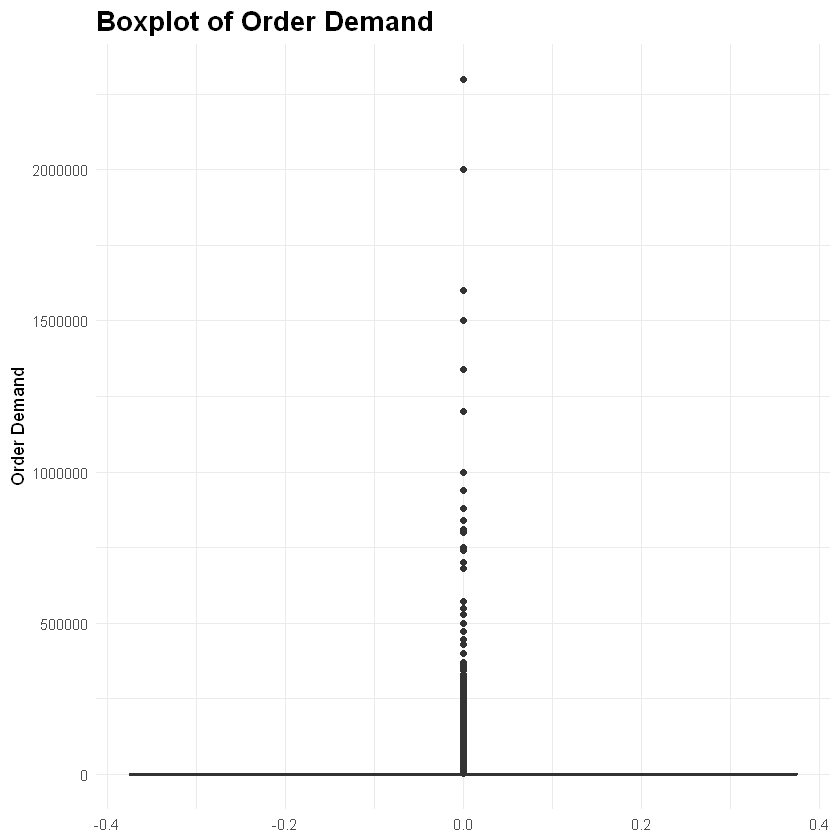

Lower Bound: -2950 
Upper Bound: 4970 
Number of Outliers: 12379 


,Product_id,Product_Code,Warehouse,Product_Category,Date,Order_Demand,Open,Promo,StateHoliday,SchoolHoliday,Petrol_price
,<int>,<chr>,<chr>,<chr>,<date>,<dbl>,<int>,<int>,<chr>,<int>,<int>
1,786725,Product_0033,Whse_S,Category_005,0001-03-20,16000,1,0,0,0,91
2,786743,Product_1825,Whse_S,Category_006,0001-03-20,50000,1,0,0,0,85
3,899734,Product_0982,Whse_A,Category_028,0001-03-20,5000,1,0,0,0,92
4,786962,Product_1263,Whse_S,Category_019,0001-03-20,15000,1,0,0,0,85
5,907388,Product_1101,Whse_C,Category_032,0001-04-20,10000,1,0,0,0,89
6,903939,Product_1970,Whse_C,Category_005,0001-04-20,10000,1,0,0,0,95


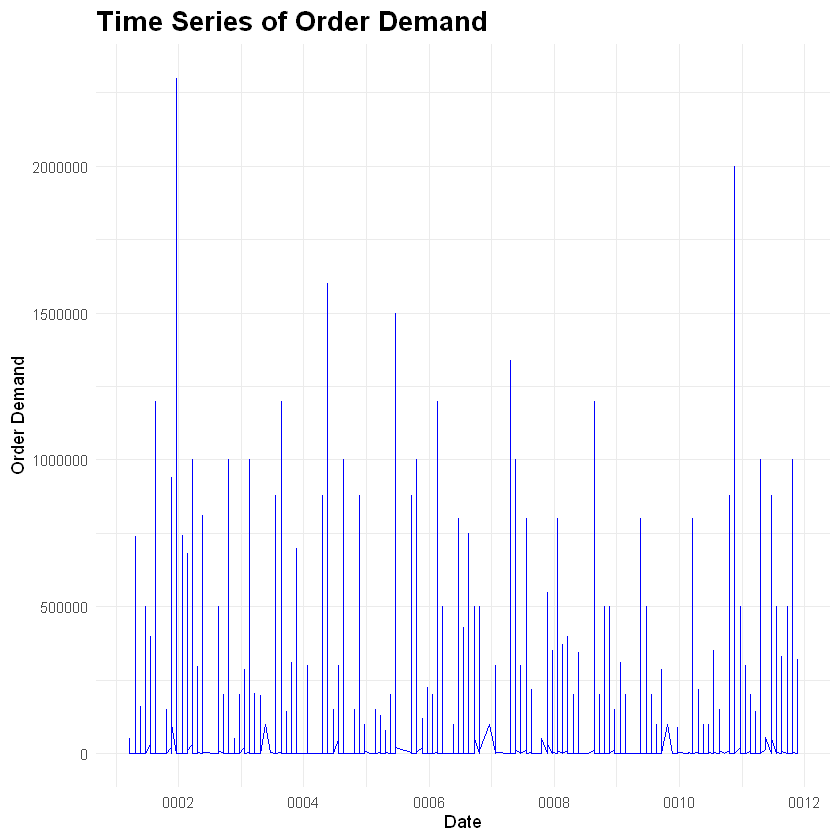

Original rows: 67792 
Cleaned rows: 55413 


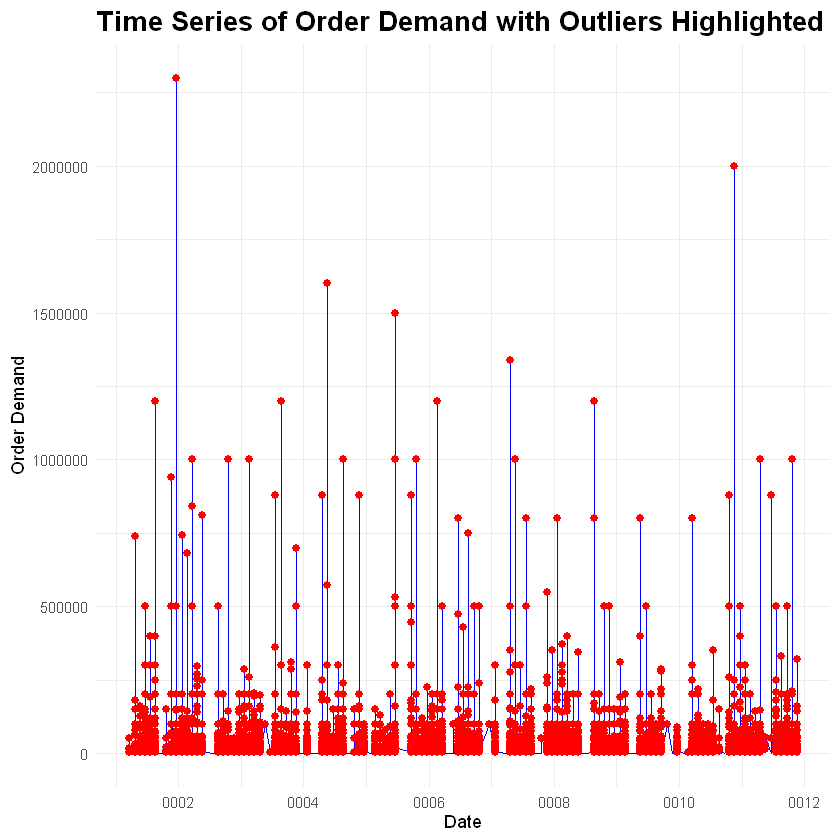

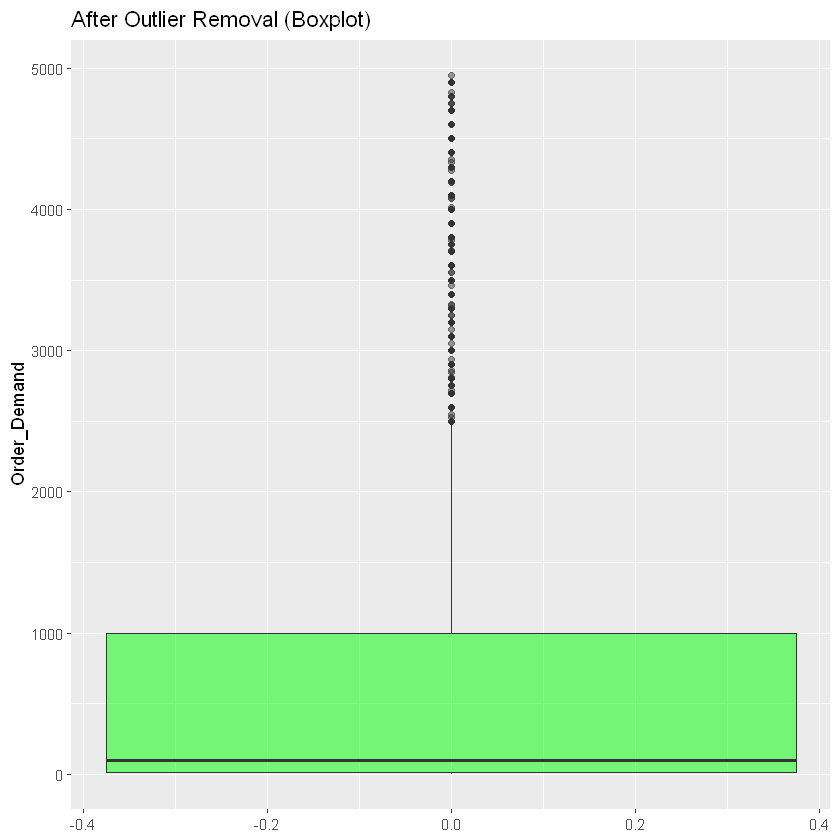

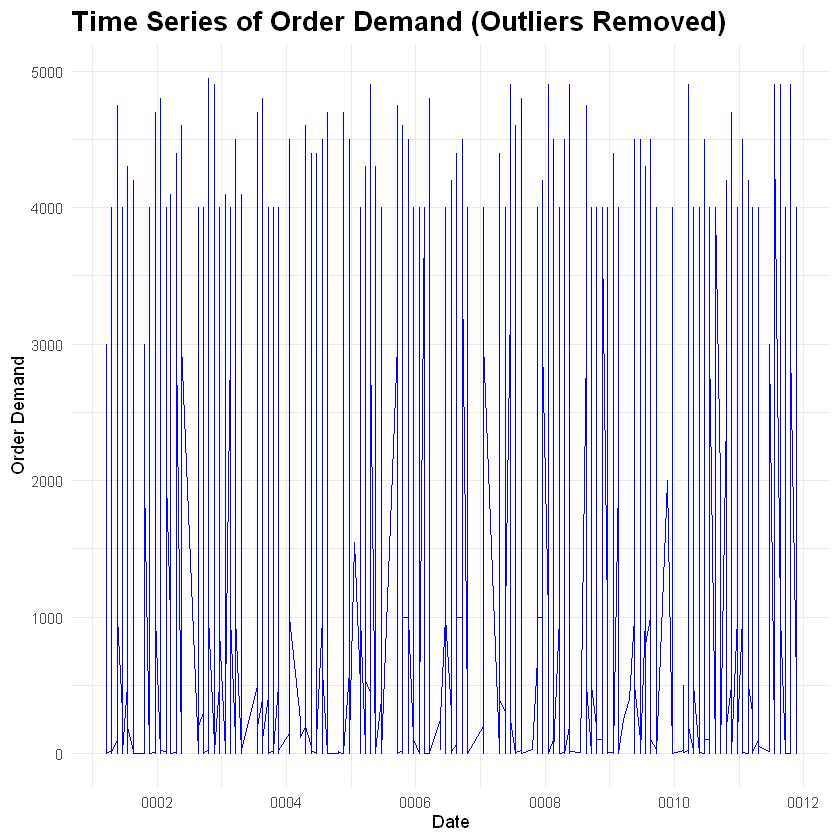

In [44]:
#Boxplot (Best for Outliers)
ggplot(data, aes(y = Order_Demand)) +
  geom_boxplot() +
  labs(title = "Boxplot of Order Demand", y = "Order Demand") +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 16))

  ## TIME SERIES PLOT
ggplot(data, aes(x = Date, y = Order_Demand)) +
  geom_line(color = "blue") +
    labs(title = "Time Series of Order Demand", x = "Date", y = "Order Demand") +
    theme_minimal() +
    theme(plot.title = element_text(face = "bold", size = 16))

## Detect Outliers (IQR Method)
Q1 <- quantile(data$Order_Demand, 0.25)
Q3 <- quantile(data$Order_Demand, 0.75)
IQR <- Q3 - Q1
lower_bound <- Q1 - 1.5 * IQR
upper_bound <- Q3 + 1.5 * IQR
outliers <- data %>% filter(Order_Demand < lower_bound | Order_Demand > upper_bound)
cat("Lower Bound:", lower_bound, "\n")
cat("Upper Bound:", upper_bound, "\n")
cat("Number of Outliers:", nrow(outliers), "\n")
head(outliers)

# Highlight Outliers in Plot
ggplot(data, aes(x = Date, y = Order_Demand)) +
  geom_line(color = "blue") +
  geom_point(data = outliers, aes(x = Date, y = Order_Demand), color = "red", size = 2) +
  labs(title = "Time Series of Order Demand with Outliers Highlighted", x = "Date", y = "Order Demand") +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 16))


  ## Remove Outliers
data_clean <- data %>% filter(Order_Demand >= lower_bound & Order_Demand <= upper_bound)
cat("Original rows:", nrow(data), "\n")
cat("Cleaned rows:", nrow(data_clean), "\n")



## Visualize AFTER Outlier Removal
ggplot(data_clean, aes(y = Order_Demand)) +
  geom_boxplot(fill = "green", alpha = 0.5) +
  ggtitle("After Outlier Removal (Boxplot)")

ggplot(data_clean, aes(x = Date, y = Order_Demand)) +
  geom_line(color = "blue") +
  labs(title = "Time Series of Order Demand (Outliers Removed)", x = "Date", y = "Order Demand") +
  theme_minimal() +
  theme(plot.title = element_text(face = "bold", size = 16))


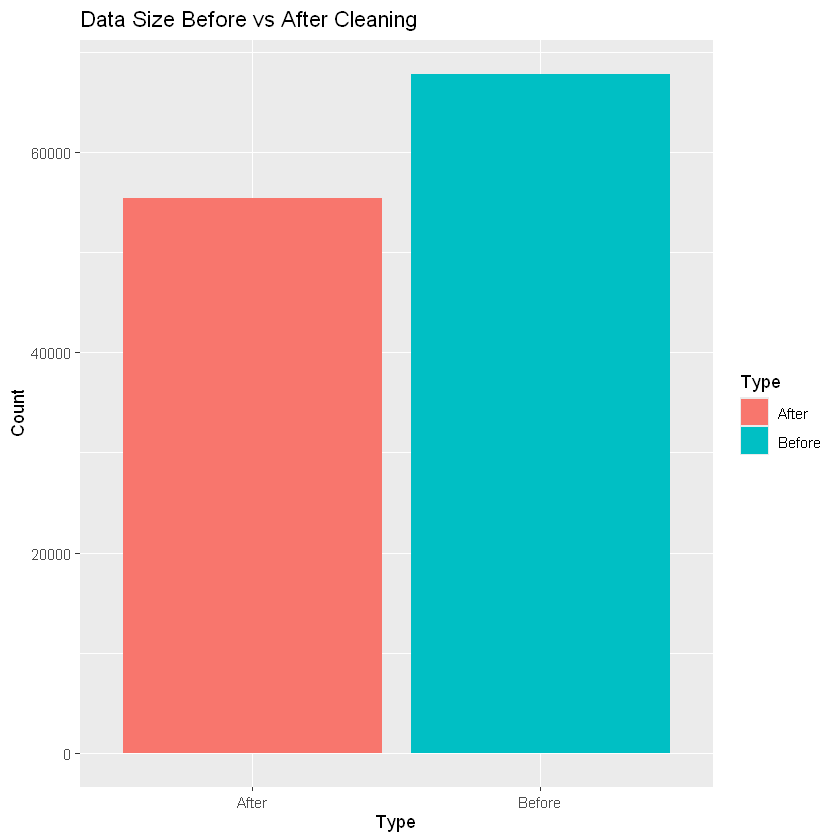

In [45]:
## Compare Before vs After
comparison <- data.frame(
  Type = c("Before", "After"),
  Count = c(nrow(data), nrow(data_clean))
)

ggplot(comparison, aes(x = Type, y = Count, fill = Type)) +
  geom_bar(stat = "identity") +
  ggtitle("Data Size Before vs After Cleaning")

In [46]:
summary(data_clean$Order_Demand)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      0      10     100     581    1000    4950 